<a href="https://colab.research.google.com/github/gomathijss-create/Crop-Yield-Analysis-and-Data-Cleaning-using-Python/blob/main/Crop_Yield_Analysis_and_Data_Cleaning_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Crop Yield Analysis and Data Cleaning using Python**

# **Objective**

1. To uncover meaningful patterns and correlations between macro-climatic factors (temperature, rainfall, humidity) and the risk spikes of regional pest infestations.

2. To identify the specific combinations of crop varieties and soil types that yield the highest production efficiency.

3. To evaluate the mathematical relationship between resource inputs (irrigation volume and pesticide metrics) and overall crop tonnage output to see if heavy resource usage translates into profitable gains.

4. To provide data-backed, actionable recommendations and strategy optimizations for regional farm operators and agricultural stakeholders based on historical trends.

# **Outcome**

This project delivers a robust data cleaning pipeline that transforms messy, unstandardized raw agricultural records into a reliable dataset. By pairing this clean data with insightful visualizations, the analysis provides stakeholders with clear, evidence-based findings to optimize crop yields and resource efficiency.

# **Domain**
**Agriculture**

#**Dataset Information**

**Source:** •	Official Data Portal link: <font color="blue"><u> **https://www.fao.org/faostat/en/#home**</font></u>

•	**Primary Governing Authority:** Food and Agriculture Organization of the United Nations (FAO)

**Dataset Column/features Description:**

* **Plot_ID** - The unique identification code assigned to each individual farm plot.

* **Region** - The geographical location or zone where the farm plot is situated.

* **Crop_Type** - The specific variety of crop being cultivated on the plot (e.g., Wheat, Rice, Cotton).

* **Soil_Type** - The texture or classification of the soil in that particular plot (e.g., Clay, Sandy, Loamy).

* **Fertilizer_Used** - Indicates whether fertilizers were applied to the crops during the season (Yes/No).

* **Irrigation_Water_Liters** - The total volume of water used to irrigate the farm plot, measured in liters.

* **Pesticide_Use_Kg** - The total quantity of pesticides applied to protect the crops, measured in kilograms.

* **Crop_Yield_MT** - The total weight of the final crop harvested from the plot, measured in Metric Tons.

* **Seasonal_Temp_C** - The average atmospheric temperature recorded during the crop cycle in degrees Celsius.

* **Rainfall_mm** - The total amount of seasonal rainfall received by the farm plot, measured in millimeters.

* **Humidity_Pct** - The average percentage of moisture in the air during the growing season.

* **Pest_Infestation_Level** - The recorded severity level of pest attacks on the crops (Low, Medium, High).

* **Farm_Size_Acres** - The total physical land area of the farm plot, measured in acres.

# **Initial EDA**

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("https://github.com/gomathijss-create/Crop-Yield-Analysis-and-Data-Cleaning-using-Python/raw/refs/heads/main/real_crop_data.csv")
df.head()

,Plot_ID,Region,Crop_Type,Soil_Type,Fertilizer_Used,Irrigation_Water_Liters,Pesticide_Use_Kg,Crop_Yield_MT,Seasonal_Temp_C,Rainfall_mm,Humidity_Pct,Pest_Infestation_Level,Farm_Size_Acres
0,PLOT_1000,East,Soybeans,?,no,68091.025428,38.704300,602.13 MT,11.889605,2205.920977,85.9 %,High,525.837932
1,PLOT_1001,North,Cotton,Clay,Yes,31494.520439,86.846339,799.08 MT,18.693254,2122.419924,89.4 %,High,665.971034
2,PLOT_1002,West,Maize,Sandy,N,4786.265332,53.760755,1575.23 MT,13.320203,987.569155,67.5 %,LOW,646.902908
3,PLOT_1003,East,Cotton,?,N,51589.229608,29.318496,613.29 MT,19.453505,2233.783741,72.8 %,High,769.562635
4,PLOT_1004,Southwest,Cotton,Sandy,Y,57497.420386,96.459950,663.14mt,12.897903,1571.745798,50.4 %,Medium,901.655905


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plot_ID                  1010 non-null   object 
 1   Region                   1010 non-null   object 
 2   Crop_Type                1010 non-null   object 
 3   Soil_Type                1010 non-null   object 
 4   Fertilizer_Used          1010 non-null   object 
 5   Irrigation_Water_Liters  1010 non-null   float64
 6   Pesticide_Use_Kg         1000 non-null   float64
 7   Crop_Yield_MT            1010 non-null   object 
 8   Seasonal_Temp_C          1010 non-null   float64
 9   Rainfall_mm              1000 non-null   float64
 10  Humidity_Pct             1010 non-null   object 
 11  Pest_Infestation_Level   889 non-null    object 
 12  Farm_Size_Acres          1010 non-null   float64
dtypes: float64(5), object(8)
memory usage: 102.7+ KB


In [ ]:
df.describe()

,Irrigation_Water_Liters,Pesticide_Use_Kg,Seasonal_Temp_C,Rainfall_mm,Farm_Size_Acres
count,1010.000000,1000.000000,1010.000000,1000.000000,1010.000000
mean,42425.366782,68.603178,25.435192,1461.352174,4559.055182
std,21956.658416,36.446255,10.622184,643.519491,62801.168372
min,-999.000000,5.226504,-45.000000,352.091188,-1.000000
25%,24229.464401,37.277451,17.037407,914.493737,301.312703
50%,42825.669570,69.273337,25.404156,1452.813870,607.369805
75%,61531.958920,100.551433,33.351852,2014.390542,915.706611
max,99999.000000,129.967659,82.000000,2594.415795,999999.000000


In [ ]:
df.shape

(1010, 13)

In [ ]:
df.isnull().sum()

,0
Plot_ID,0
Region,0
Crop_Type,0
Soil_Type,0
Fertilizer_Used,0
Irrigation_Water_Liters,0
Pesticide_Use_Kg,10
Crop_Yield_MT,0
Seasonal_Temp_C,0
Rainfall_mm,10


In [ ]:
df.duplicated().sum()

np.int64(10)

# **Data Cleaning and Pre-processing**

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Printing the raw unique values of our text columns
print(df['Region'].unique())
print(df['Fertilizer_Used'].unique())
print(df['Pest_Infestation_Level'].unique())

['East' 'North' 'West' 'Southwest' 'South' ' West ' 'East ' 'NORTH']
['no' 'Yes' ' N ' ' Y ' 'No' 'yes' 'YES']
['High  ' 'High' 'LOW' 'Medium' '?' 'Low' nan 'Medium ']


In [ ]:
print(df['Crop_Type'].unique())
print(df['Soil_Type'].unique())

['Soybeans' 'Cotton' 'Maize' 'Rice' 'Wheat']
['?' 'Clay' 'Sandy' 'Loamy' 'Silt' 'Unknown']


In [ ]:
# Creating a clean copy of the dataframe to track changes
df_cleaned = df.copy()

df_cleaned['Region'] = df_cleaned['Region'].astype(str).str.strip().str.title()

df_cleaned['Pest_Infestation_Level'] = df_cleaned['Pest_Infestation_Level'].astype(str).str.strip().str.title()

df_cleaned['Pest_Infestation_Level'] = df_cleaned['Pest_Infestation_Level'].replace({'?': 'Unknown'})

df_cleaned['Fertilizer_Used'] = df_cleaned['Fertilizer_Used'].astype(str).str.strip().str.upper()

fertilizer_mapping = {
    'Y': 'Yes',
    'YES': 'Yes',
    'N': 'No',
    'NO': 'No'
}
df_cleaned['Fertilizer_Used'] = df_cleaned['Fertilizer_Used'].replace(fertilizer_mapping)

print(df_cleaned['Region'].unique())
print(df_cleaned['Fertilizer_Used'].unique())
print(df_cleaned['Pest_Infestation_Level'].unique())

['East' 'North' 'West' 'Southwest' 'South']
['No' 'Yes']
['High' 'Low' 'Medium' 'Unknown' 'Nan']


In [ ]:
# Grouping 'Nan' and 'Unknown' into a single uniform category
df_cleaned['Pest_Infestation_Level'] = df_cleaned['Pest_Infestation_Level'].replace({'Nan': 'Unknown'})

print(df_cleaned['Pest_Infestation_Level'].unique())

['High' 'Low' 'Medium' 'Unknown']


In [ ]:
df_cleaned['Pest_Infestation_Level'] = df_cleaned['Pest_Infestation_Level'].replace('Unknown', 'Uninspected')

In [ ]:
# Showing the count of all categories in the column
print(df_cleaned['Pest_Infestation_Level'].value_counts())

Pest_Infestation_Level
Low            261
Uninspected    257
High           251
Medium         231
Name: count, dtype: int64


In [ ]:
print(df_cleaned['Crop_Type'].unique())
print(df_cleaned['Soil_Type'].unique())

['Soybeans' 'Cotton' 'Maize' 'Rice' 'Wheat']
['?' 'Clay' 'Sandy' 'Loamy' 'Silt' 'Unknown']


In [ ]:
df_cleaned['Soil_Type'] = df_cleaned['Soil_Type'].replace({'?': 'Unknown'})
print(df_cleaned['Soil_Type'].unique())

['Unknown' 'Clay' 'Sandy' 'Loamy' 'Silt']


In [ ]:
print(df_cleaned['Soil_Type'].value_counts())

Soil_Type
Loamy      349
Clay       239
Sandy      208
Unknown    150
Silt        54
Name: count, dtype: int64


In [ ]:
soil_mode = df_cleaned[df_cleaned['Soil_Type'] != 'Unknown']['Soil_Type'].mode()[0]
print(f"The most frequent Soil_Type (Mode) is: {soil_mode}")

The most frequent Soil_Type (Mode) is: Loamy


In [ ]:
df_cleaned['Soil_Type'] = df_cleaned['Soil_Type'].replace({'Unknown': soil_mode})
print(df_cleaned['Soil_Type'].unique())

['Loamy' 'Clay' 'Sandy' 'Silt']


In [ ]:
# 1. Clean 'Crop_Yield_MT': Strip 'MT', remove spaces, and convert to float
df_cleaned['Crop_Yield_MT'] = df_cleaned['Crop_Yield_MT'].astype(str).str.replace('MT', '', case=False).str.strip()
df_cleaned['Crop_Yield_MT'] = pd.to_numeric(df_cleaned['Crop_Yield_MT'], errors='coerce')

# 2. Clean 'Humidity_Pct': Strip '%', remove spaces, and convert to float
df_cleaned['Humidity_Pct'] = df_cleaned['Humidity_Pct'].astype(str).str.replace('%', '').str.strip()
df_cleaned['Humidity_Pct'] = pd.to_numeric(df_cleaned['Humidity_Pct'], errors='coerce')

print(df_cleaned[['Crop_Yield_MT', 'Humidity_Pct']].dtypes)

print(df_cleaned[['Crop_Yield_MT', 'Humidity_Pct']])

Crop_Yield_MT    float64
Humidity_Pct     float64
dtype: object
     Crop_Yield_MT  Humidity_Pct
0           602.13          85.9
1           799.08          89.4
2          1575.23          67.5
3           613.29          72.8
4           663.14          50.4
..             ...           ...
995        1285.03          75.7
996          21.18          45.6
997         410.51          78.0
998          70.42          77.4
999        2809.80          49.1

[1000 rows x 2 columns]


In [ ]:
# removing unrealistic values
df_cleaned['Irrigation_Water_Liters'] = df_cleaned['Irrigation_Water_Liters'].replace([-999, 99999], np.nan)
df_cleaned.loc[(df_cleaned['Seasonal_Temp_C'] < -10) | (df_cleaned['Seasonal_Temp_C'] > 60), 'Seasonal_Temp_C'] = np.nan
df_cleaned['Farm_Size_Acres'] = df_cleaned['Farm_Size_Acres'].replace([-1, 999999], np.nan)

In [ ]:
df_cleaned.isnull().sum()

,0
Plot_ID,0
Region,0
Crop_Type,0
Soil_Type,0
Fertilizer_Used,0
Irrigation_Water_Liters,10
Pesticide_Use_Kg,10
Crop_Yield_MT,0
Seasonal_Temp_C,6
Rainfall_mm,10


In [ ]:
all_numeric_nulls = [
    'Pesticide_Use_Kg',
    'Rainfall_mm',
    'Irrigation_Water_Liters',
    'Farm_Size_Acres',
    'Seasonal_Temp_C'
]

for col in all_numeric_nulls:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned.groupby('Crop_Type')[col].transform('median'))

In [ ]:
df_cleaned.isnull().sum()

,0
Plot_ID,0
Region,0
Crop_Type,0
Soil_Type,0
Fertilizer_Used,0
Irrigation_Water_Liters,0
Pesticide_Use_Kg,0
Crop_Yield_MT,0
Seasonal_Temp_C,0
Rainfall_mm,0


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plot_ID                  1000 non-null   object 
 1   Region                   1000 non-null   object 
 2   Crop_Type                1000 non-null   object 
 3   Soil_Type                1000 non-null   object 
 4   Fertilizer_Used          1000 non-null   object 
 5   Irrigation_Water_Liters  1000 non-null   float64
 6   Pesticide_Use_Kg         1000 non-null   float64
 7   Crop_Yield_MT            1000 non-null   float64
 8   Seasonal_Temp_C          1000 non-null   float64
 9   Rainfall_mm              1000 non-null   float64
 10  Humidity_Pct             1000 non-null   float64
 11  Pest_Infestation_Level   1000 non-null   object 
 12  Farm_Size_Acres          1000 non-null   float64
dtypes: float64(7), object(6)
memory usage: 109.4+ KB


In [ ]:
df_cleaned.describe()

,Irrigation_Water_Liters,Pesticide_Use_Kg,Crop_Yield_MT,Seasonal_Temp_C,Rainfall_mm,Humidity_Pct,Farm_Size_Acres
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,42337.447798,68.789925,1714.319690,25.493990,1460.691555,65.377100,603.299408
std,21392.503404,36.243982,1592.151915,9.411537,642.229541,17.116696,342.667571
min,4103.019862,5.226504,9.540000,10.020081,352.091188,35.100000,15.221036
25%,24408.608240,37.855701,482.960000,17.071310,917.270836,51.000000,308.589623
50%,42692.942855,69.536197,1246.035000,25.473991,1464.685392,66.050000,608.854826
75%,60847.583374,100.383951,2422.482500,33.311236,2013.288405,79.900000,906.748100
max,79948.036382,129.967659,10054.260000,41.995176,2594.415795,95.000000,1197.183044


In [ ]:
# Creating an independent, safe copy for our clean data
dataset = df_cleaned.copy()

# **EDA and Visualizations**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# **Ranking Average Crop Yield by Crop Type**

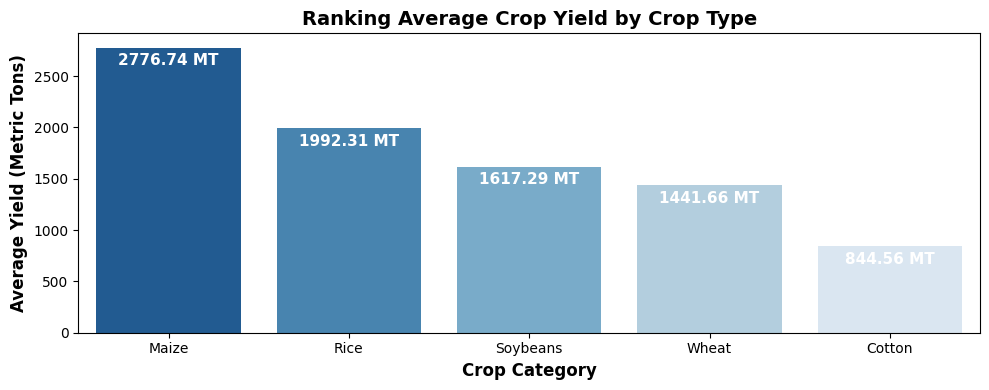

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average yield per crop type and sort them in descending order
sorted_order = dataset.groupby('Crop_Type')['Crop_Yield_MT'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=dataset,
    x='Crop_Type',
    y='Crop_Yield_MT',
    order=sorted_order,
    palette='Blues_r',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f MT', padding=-15, color='white', fontweight='bold', fontsize=11)

plt.title('Ranking Average Crop Yield by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Category', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (Metric Tons)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation of above chart

* Plotted bar chart to compare crop type and crop yield

* By comparing crop type and their yield in metric tons **'Maize'** ranks higher with 2776.74 MT whereas **'Cotton'** ranks least with 844.56 MT.

* Features used - crop category and Average yield in MT

* Calculated the average yield per crop type and sorted them in descending order for quick spotting.

# **Average Crop Yield by Crop Type and Soil Type**

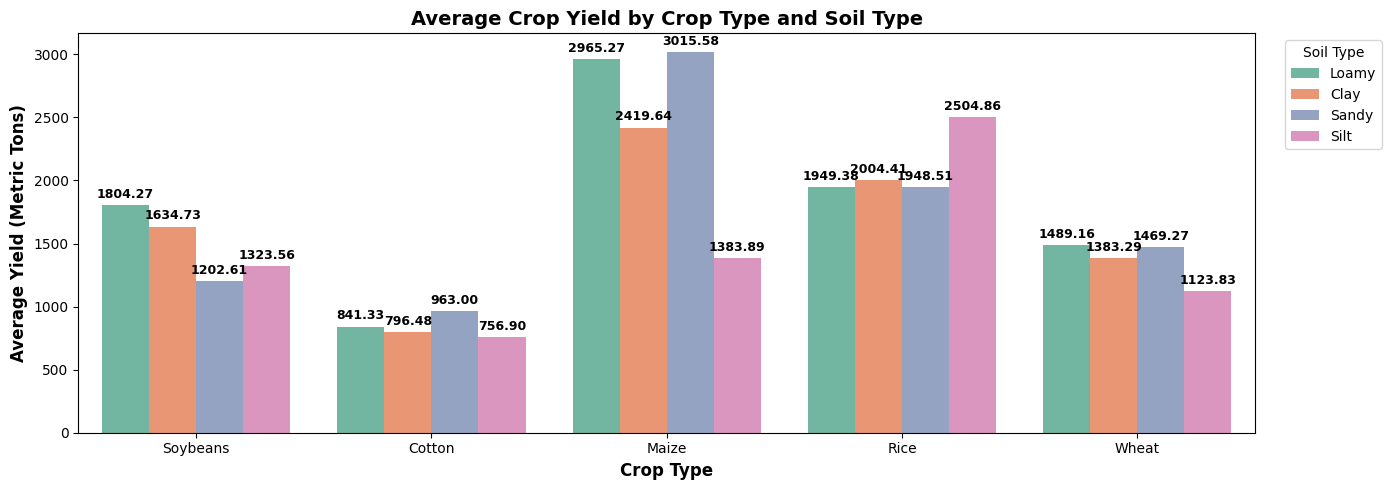

In [ ]:
plt.figure(figsize=(14, 5))

# Create the grouped bar chart
ax = sns.barplot(
    data=dataset,
    x='Crop_Type',
    y='Crop_Yield_MT',
    hue='Soil_Type',
    palette='Set2',  # A clean, distinct color palette for the soil types
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')

plt.title('Average Crop Yield by Crop Type and Soil Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (Metric Tons)', fontsize=12, fontweight='bold')

plt.legend(title='Soil Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## Interpretation of above chart

* Used grouped bar chart to uncover crop yield based on the type of soil where the crop is cultivated.

* Comparing the all types of soil the Soybeans(1804.27 MT) and Wheat(1489.16 MT)  gives good yield in Loamy soil , Cotton(963.00 MT)  and Maize(3015.58 MT) gives good yield in Sandy soil, Rice(2504.86 MT) gives good yield in Silt soil.

* Used features crop type and average yield in MT.


# **Relationship Between Rainfall and Crop Yield**

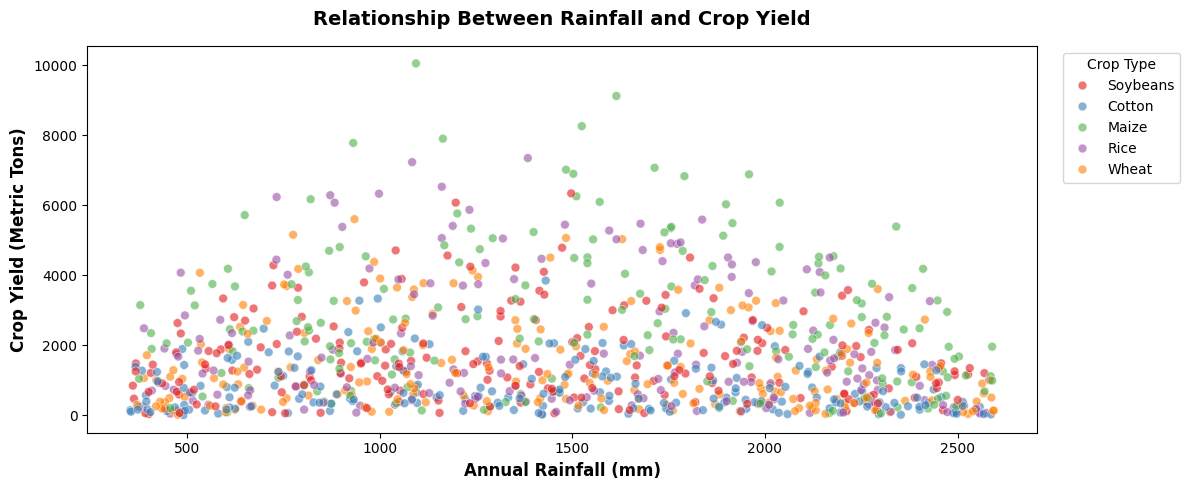

In [ ]:
plt.figure(figsize=(12, 5))
# 2. Create the scatter plot
sns.scatterplot(
    data=dataset,
    x='Rainfall_mm',
    y='Crop_Yield_MT',
    hue='Crop_Type',
    palette='Set1',        # Uses sharp, distinct colors for each crop
    alpha=0.6,             # Makes dots slightly see-through so overlapping dots are visible
    s=40                   # Sets the size of the dots
)

plt.title('Relationship Between Rainfall and Crop Yield', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Crop Yield (Metric Tons)', fontsize=12, fontweight='bold')

plt.legend(title='Crop Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## Interpretation of above chart

* Used scatter plot to find relationship between annual rainfall and crop yield.

* It shows that crop yields peak dynamically between 1000 mm and 1600 mm of rainfall, while extreme droughts (low rainfall) or flooding (high rainfall) suppress overall growth.

* Features used - Annual rainfall(mm) and crop yield(MT)

* It illustrates the optimal climate zones for agricultural output, proving that mid-range annual rainfall maximizes yield performance across all crop types.

# **Correlation Heatmap: Agricultural & Environmental Factors**

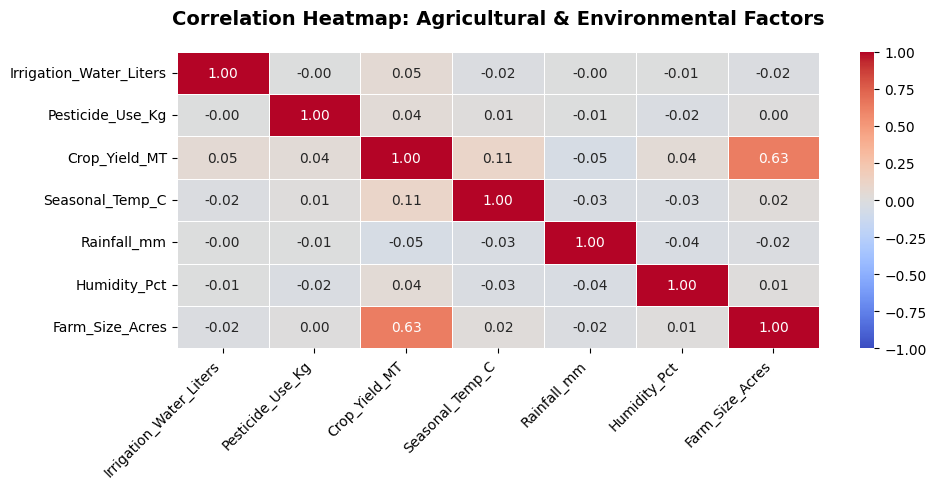

In [ ]:
plt.figure(figsize=(10, 5))
numeric_df = dataset.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Correlation Heatmap: Agricultural & Environmental Factors', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

## Interpretation of above chart

* Used correlation heatmap to find the relation between agricultural and environmental factors.

* It shows that Farm_Size_Acres has a strong positive correlation (0.63) with Crop_Yield_MT, while other factors like rainfall, temperature, and tracking metrics show near-zero linear correlations across the entire dataset.

* The chart evaluates seven numerical features, including Irrigation_Water_Liters, Pesticide_Use_Kg, Crop_Yield_MT, Seasonal_Temp_C, Rainfall_mm, Humidity_Pct, and Farm_Size_Acres.

* It illustrates that physical land scale is the dominant linear driver of total harvest volume.

# **Percentage Contribution to Total Crop Yield by Region**

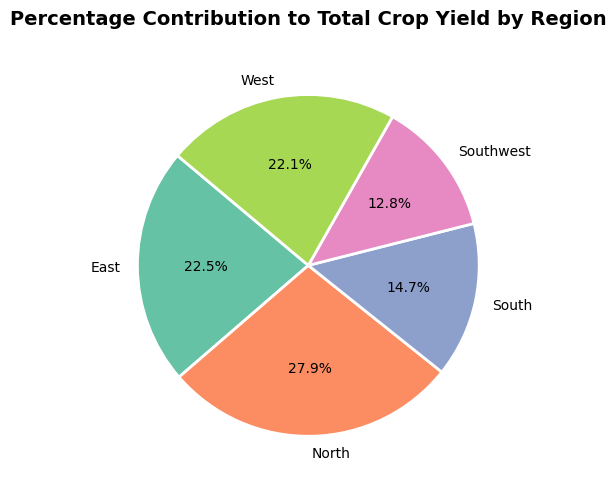

In [ ]:
import matplotlib.pyplot as plt
region_yields = dataset.groupby('Region')['Crop_Yield_MT'].sum()
plt.figure(figsize=(5, 5))

plt.pie(
    region_yields,
    labels=region_yields.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Percentage Contribution to Total Crop Yield by Region', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Interpretation of above chart

* This is a pie chart that displays the percentage breakdown of total crop yield production contributed by each geographic region.

* It shows that the North region is the top producer at 27.9%, followed closely by East (22.5%) and West (22.1%), while the Southwest contributes the least at 12.8%.

* The chart groups the data by the categorical feature Region and calculates the sum total of Crop_Yield_MT.

* It illustrates the macro-distribution of your agricultural output, identifying which regions serve as major supply hubs and which ones have lower production shares.

# **Average Crop Yield Comparison: Fertilizer vs. No Fertilizer**

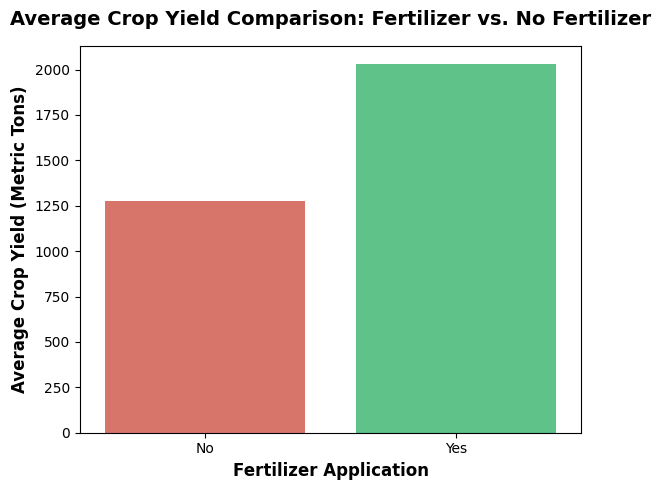

In [ ]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=dataset,
    x='Fertilizer_Used',
    y='Crop_Yield_MT',
    palette=['#e74c3c', '#2ecc71'],
    errorbar=None,
    alpha=0.85,
    )

plt.title('Average Crop Yield Comparison: Fertilizer vs. No Fertilizer', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fertilizer Application', fontsize=12, fontweight='bold')
plt.ylabel('Average Crop Yield (Metric Tons)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretation of above chart

* This is a bar chart comparing the absolute mathematical mean crop yields between fields that utilized fertilizer and those that did not.

* It shows that fields with fertilizer application achieve a much higher average yield of roughly 2,025 Metric Tons compared to unfertilized fields, which average around 1,275 Metric Tons.

* The chart uses the categorical column Fertilizer_Used on the X-axis and calculates the mean of the numerical column Crop_Yield_MT on the Y-axis.

* It provides a clean, executive-level confirmation that applying fertilizer yields a massive, quantifiable increase of approximately 750 Metric Tons per farm plot on average.

## **Downloading cleaned data for dashboard creation using Power BI**


In [ ]:
dataset.to_csv("cleaned_crop_yield_dataset.csv", index=False)

# **Documentation, Insights and Presentation**

# **Dashboard**

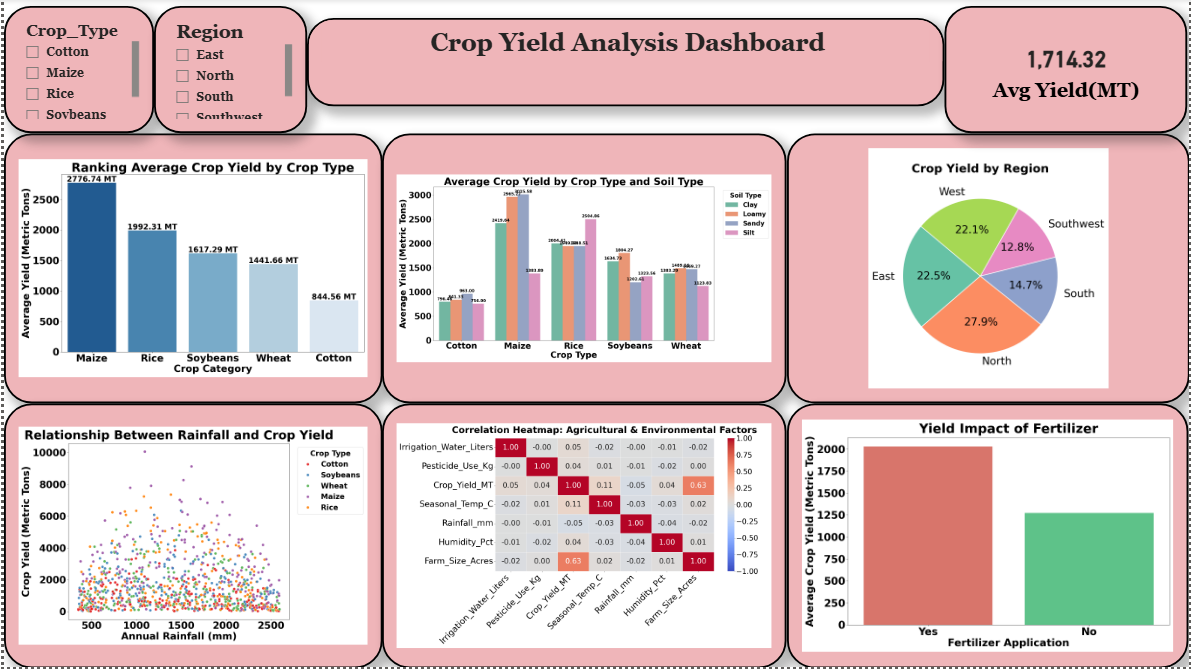

# **Insights Gathered**

* **Crop Production**: **Maize** is the dominant volume contributor with a peak average yield of **2,776.74 MT**, whereas **Cotton** registers the lowest footprint at **844.56 MT**.

* **Regional Contribution**: Total agricultural production is highly concentrated in three zones: the **North (27.9%)**, followed closely by the **East (22.5%)** and **West (22.1%)**, while the **Southwest** lags significantly behind as the lowest producer at **12.8%**.

* **Resource Impact**: Farm plots treated with fertilizer achieve a substantially higher average output of **~2,025 MT**, compared to unfertilized plots which stop at **~1,275 MT** (a clear **750 MT** production gap).

* **Scale Driven Growth**: The strongest mathematical driver of harvest volume is physical land scale, proved by a strong positive correlation of **0.63** between **Farm_Size_Acres** and **Crop_Yield_MT**.

* **Environmental & Soil Preferences**: Specific crop yields are highly sensitive to their soil mediums. Soybeans **(1,804.27 MT)** and Wheat **(1,489.16 MT)** thrive optimally in Loamy soil; Maize **(3,015.58 MT)** and Cotton **(963.00 MT)** adapt best to Sandy soil; while Rice **(2,504.86 MT)** maximizes its performance strictly in Silt soil.

* **The Rainfall Sweet-Spot**: Yields do not scale infinitely with water. There is an optimal climate zone where crop yields peak dynamically between **1,000 mm and 1,600 mm** of annual rainfall. Beyond this window, extreme drought or flooding conditions act as stressors that suppress overall growth.



# **Recommendations**

* **Implement Precise Soil-to-Crop Mapping**: Mandate regional crop distribution strategies that align crops with their top-performing soil environments (e.g., dedicate Sandy soils entirely to Maize/Cotton and Silt basins exclusively to Rice).

* **Scale Fertilizer Deployment**: Prioritize fertilizer distribution frameworks to unfertilized or underperforming farm plots, as this single management practice guarantees an average yield lift of roughly **750 MT** per plot.

* **Target Regional Infrastructure in the Southwest**: Investigate the structural bottlenecks causing the Southwest region to produce a mere **12.8%** of total output. Deploy irrigation systems or land consolidation efforts there to build resilience against its lower yields.

* **Develop Climate-Resilient Water Management**: For regions experiencing rainfall outside the optimal **1,000 mm – 1,600 mm** boundary, install smart drainage systems to handle flooding and water-retention basins/reservoirs to safeguard against droughts.

# stage 4 pdf Link
Stage4_doc link : <font color="blue"><u> **https://drive.google.com/drive/folders/1286sTMUGCz2umFKfqAj8QD51INzB-iUK?usp=sharing**</font></u>

# Conclusion

From the analysis, we identified meaningful relationships and patterns in the agricultural dataset. The visualizations and multi-variable insights highlight that physical land scale, strategic fertilizer deployment, the optimal rainfall spot and precise crop-to-soil mapping are the dominant factors influencing crop yields and this analysis provides a strong, data-driven foundation for maximizing future harvest volumes and making smarter, evidence-based farming decisions.